Question 1:
# What are the most demanded skills for the top 3 most popular data roles?

# Methodology:

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

# Importing data and libraries

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data - only data for 2023
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

# Loading Data - 2023, 2024, 2025 and first half of 2026:
df = pd.read_csv(r"C:\Users\Nikola S\Desktop\Luke B\job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns

# Filter Data for the Serbia

In [3]:
df_SRB = df[df["job_country"] == "Serbia"]
df_skilss = df_SRB.explode("job_skills")

In [4]:
df_skilss[["job_title_short", "job_skills"]]
df_skilss_count = df_skilss.groupby(["job_skills", "job_title_short"]).size()
df_skilss_count = df_skilss_count.reset_index(name="count of skills").sort_values(by="count of skills", ascending=False)

In [5]:
df_skilss_count

,job_skills,job_title_short,count of skills
715,sql,Data Analyst,310
716,sql,Data Engineer,310
559,python,Data Engineer,307
558,python,Data Analyst,214
560,python,Data Scientist,194
...,...,...,...
701,spring,Business Analyst,1
316,jenkins,Data Analyst,1
318,jenkins,Data Scientist,1
704,spring,Machine Learning Engineer,1


In [6]:
job_titles = df_skilss_count["job_title_short"].unique().tolist()
job_titles = sorted(job_titles)
job_titles = sorted(job_titles[2:5])
job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

# Plot Skill Counts
Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill.

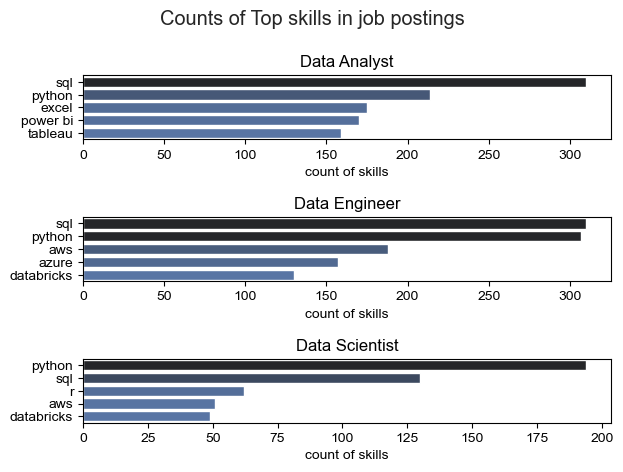

In [8]:
fig, ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skilss_count[df_skilss_count["job_title_short"] == job_title].head(5)
    #df_plot.plot(kind="barh", x="job_skills", y="count of skills", ax=ax[i], title = job_title)
    sns.barplot(data=df_plot, x="count of skills", y="job_skills", ax=ax[i],  hue="count of skills", palette="dark:b_r")
    #ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_title(job_title)
    ax[i].legend().set_visible(False)
fig.suptitle("Counts of Top skills in job postings")
fig.tight_layout()
plt.show()

In [9]:
df_job_title_count = df_SRB["job_title_short"].value_counts().reset_index(name="title_count")
df_job_title_count 

,job_title_short,title_count
0,Data Analyst,477
1,Software Engineer,440
2,Data Engineer,429
3,Data Scientist,267
4,Business Analyst,220
5,Senior Data Engineer,143
6,Senior Data Scientist,80
7,Machine Learning Engineer,72
8,Cloud Engineer,67
9,Senior Data Analyst,63


In [10]:
df_skills_perc = pd.merge(df_skilss_count, df_job_title_count, how="left", on="job_title_short")
df_skills_perc["skill_perc"] = df_skills_perc["count of skills"]/df_skills_perc["title_count"] *100

In [11]:
df_skills_perc

,job_skills,job_title_short,count of skills,title_count,skill_perc
0,sql,Data Analyst,310,477,64.989518
1,sql,Data Engineer,310,429,72.261072
2,python,Data Engineer,307,429,71.561772
3,python,Data Analyst,214,477,44.863732
4,python,Data Scientist,194,267,72.659176
...,...,...,...,...,...
837,spring,Business Analyst,1,220,0.454545
838,jenkins,Data Analyst,1,477,0.209644
839,jenkins,Data Scientist,1,267,0.374532
840,spring,Machine Learning Engineer,1,72,1.388889


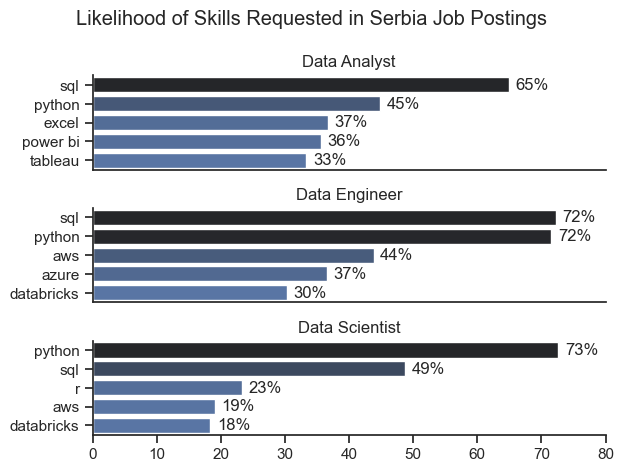

In [17]:
fig, ax = plt.subplots(len(job_titles),1)
sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc["job_title_short"] == job_title].head(5)
    sns.barplot(data=df_plot, x="skill_perc", y="job_skills", ax=ax[i],  hue="skill_perc", palette="dark:b_r")
    # df_plot.plot(kind="barh", x="job_skills", y="skill_perc", ax=ax[i], title = job_title)
    #ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_title(job_title)
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,80)
    ax[i].set_xlabel("")
    sns.despine(ax=ax[i])

    for n,v in enumerate(df_plot["skill_perc"]):
        ax[i].text(v+1, n, f"{v:.0f}%", va="center")
    if i != len(job_titles)-1:
        ax[i].set_xticks([])

fig.suptitle("Likelihood of Skills Requested in Serbia Job Postings")
fig.tight_layout()
plt.show()